In [3]:
import os

# Download EuroSAT from torchvision directly — most reliable method
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# This downloads and sets up EuroSAT automatically
dataset = datasets.EuroSAT(
    root="./data",
    transform=transforms.ToTensor(),
    download=True
)

print(f"Total images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 233MB/s] 


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Image shape: torch.Size([3, 64, 64])
Image dtype: torch.float32
Pixel range: 0.32 to 0.80
Label: 0 = AnnualCrop


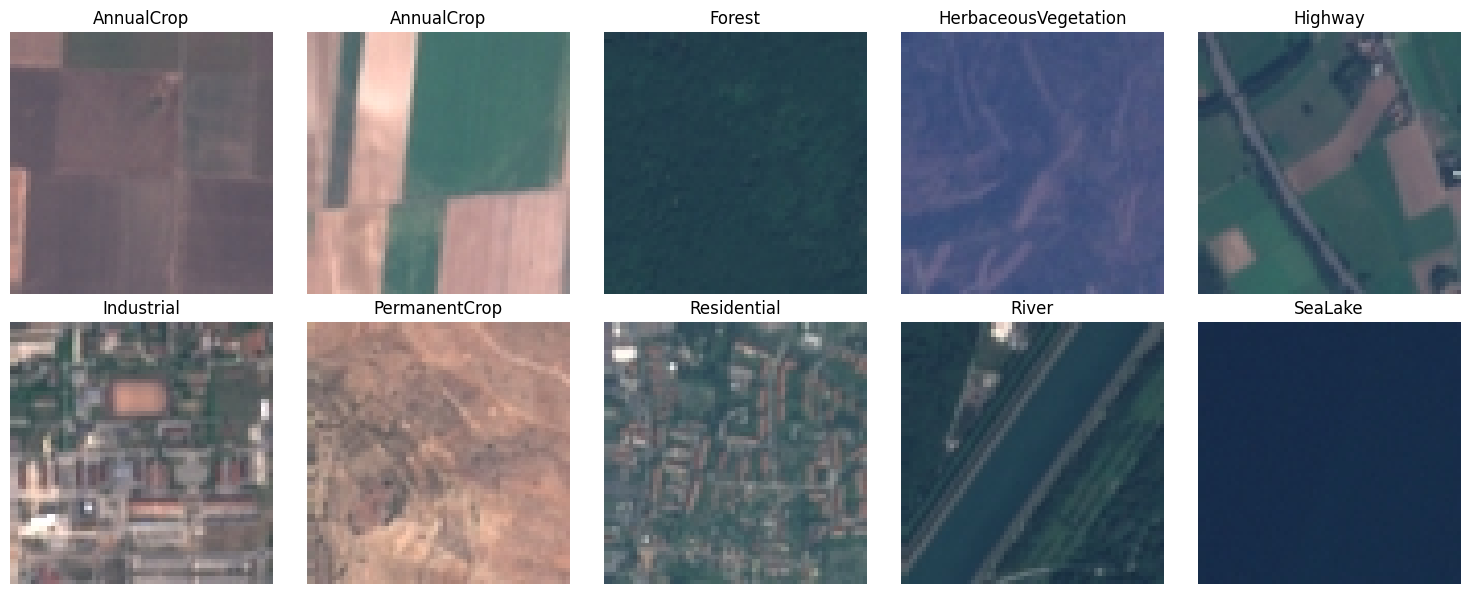

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Look at one sample
image, label = dataset[0]
print(f"Image shape: {image.shape}")       # (C, H, W)
print(f"Image dtype: {image.dtype}")
print(f"Pixel range: {image.min():.2f} to {image.max():.2f}")
print(f"Label: {label} = {dataset.classes[label]}")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img, lbl = dataset[i * 2700]    # one from each class
    img = img.permute(1, 2, 0)      # (C,H,W) → (H,W,C) for matplotlib
    ax.imshow(img)
    ax.set_title(dataset.classes[lbl])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from torch.utils.data import DataLoader, random_split

# Split dataset — 80% train, 20% validation
train_size = int(0.8 * len(dataset))   # 21,600
val_size = len(dataset) - train_size   # 5,400

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

# DataLoader — batches + shuffles data automatically
train_loader = DataLoader(
    train_dataset,
    batch_size=32,        # 32 images per step
    shuffle=True,         # shuffle every epoch
    num_workers=2         # parallel data loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,        # never shuffle validation
    num_workers=2
)

# Inspect one batch
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")   # (32, 3, 64, 64)
print(f"Batch label shape: {labels.shape}")     # (32,)
print(f"Labels in batch:   {labels}")


Train samples: 21600
Val samples:   5400

Batch image shape: torch.Size([32, 3, 64, 64])
Batch label shape: torch.Size([32])
Labels in batch:   tensor([4, 4, 2, 1, 6, 4, 9, 4, 3, 1, 8, 4, 3, 9, 3, 1, 6, 5, 0, 9, 4, 7, 2, 8,
        9, 9, 5, 8, 4, 3, 0, 8])


In [6]:
import torchvision.transforms as transforms

# EuroSAT mean and std (precomputed for this dataset)
mean = [0.3444, 0.3803, 0.4078]
std  = [0.2038, 0.1367, 0.1147]

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)   # zero-center each channel
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)   # same normalization, no augmentation
])

# Reload dataset with transforms
train_dataset = datasets.EuroSAT(root="./data", transform=train_transforms, download=False)
val_dataset   = datasets.EuroSAT(root="./data", transform=val_transforms,   download=False)

# Split again
train_dataset, val_dataset = random_split(train_dataset, [21600, 5400])

# Reload dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

# Verify
images, labels = next(iter(train_loader))
print(f"Pixel mean after normalize: {images.mean():.4f}")   # close to 0
print(f"Pixel std after normalize:  {images.std():.4f}")    # close to 1

Pixel mean after normalize: -0.1001
Pixel std after normalize:  0.8979
